---
title: Investigation of municipal snow removal services and access to education in Syracuse
subtitle: A Data Warriors project at Henninger High School
authors:  
- name: Halima Shizard 
  affiliations:
      - henninger
      - data-warriors
- name: Justin Cortes
  affiliation:
      - henninger
      - data-warriors
- name: Ushindi Cepher
  affiliations:
      - henninger
      - data-warriors
- name: Xavier Trapps
  affiliations:
      - henninger
      - data-warriors
  email: xtrapps@scsd.us
  corresponding: true
- name: Nicole Fonger
  affiliations:
      - syracuse-university
      - data-warriors
  email: nfonger@syr.edu
  orcid: 0000-0002-6245-4062
- name: Lauren Ashby
  affiliations:
      - syracuse-university
      - data-warriors
  email: leashby@syr.edu
- name: Abner Bogan  
  email: abogan@cuahsi.org
  orcid: 0009-0009-4882-3333
  github: abogan 
  affiliations:
      - cuahsi
      - data-warriors
affiliations:
  - id: cuahsi
    name: Consortium of Universities for the Advancement of Hydrologic Science, Inc.
    url: https://www.cuahsi.org/
  - id: data-warriors
    name: Data Warriors
    url: https://thedatawarriors.com/
  - id: henninger
    name: Henninger High School
    url: https://www.syracusecityschools.com/henninger
  - id: syracuse-university
    name: Syracuse University
    url: https://www.syracuse.edu/
keywords:
- Education Access
- Snow Removal
- Students
- Syracuse
---

# 1. Overview

This project was developed by a group of students in the [Data Warriors program](https://thedatawarriors.com/) at Henninger High School in Syracuse, New York. The group wanted to better understand whether students living on smaller residential streets and in different areas of Syracuse may face greater challenges getting to school in the winter than students who live on roads that are plowed more quickly.

![](images/burning_questions.png)
_Burning questions from the group (Halima, Justin and Ushindi) developed in Week 3._

This notebook walks through the process of analyzing the survey responses and combining them with other publicly available data sources, including information from the Census and the [City of Syracuse Open Data Portal](https://data.syr.gov/). These additional datasets can help explore how snow removal, neighborhood conditions, and access to school may vary across Syracuse.

This notebook will be using the [R programming language](https://www.r-project.org/) for managing data workflows. Knowledge of R is not required to interpret the contents of this notebook.

# 2. Downloading survey data

Students shared data on their project through [HydroShare](https://hydroshare.org/), an open repository for sharing and discovering water-related data and research materials. Information about the project is available here on HydroShare: [Survey of Municipal Snow Removal Services and Access to Education in Syracuse](https://www.hydroshare.org/resource/60420a30cb5143c8957709a66bf2e71c/). The survey responses themselves are not currently public. Additional consent is needed before the raw data can be shared.

## 2.1 Installing packages

In [7]:
library(tidyverse)
library(scales)
source('01_download/src/get_data_from_hydroshare.R')
source('02_process/src/process_helpers.R')
source('03_visualize/src/plotting_helpers.R')

Warning message:
"package 'tidyverse' was built under R version 4.3.3"
Warning message:
"package 'readr' was built under R version 4.3.3"
Warning message:
"package 'dplyr' was built under R version 4.3.3"
Warning message:
"package 'forcats' was built under R version 4.3.3"
Warning message:
"package 'lubridate' was built under R version 4.3.3"
── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.0     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to becom

## 2.2 Downloading survey data from HydroShare

We will programmatically download the survey data via the [HydroShare API](https://www.hydroshare.org/hsapi/). When running the cell below, you will be prompted to sign in to your HydroShare account. Note that you will need to have a HydroShare account (instructions on creating a HydroShare account are [here](https://help.hydroshare.org/introduction-to-hydroshare/getting-started/create-an-account/)) and have access to view the raw survey data.

In [9]:
# define where we want the data to be saved as zip
out_dir_zip <- '01_download/tmp'
# define the resource id (https://www.hydroshare.org/resource/{resource-id})
resource_id <- '60420a30cb5143c8957709a66bf2e71c'

In [11]:
# pull data from HydroShare
get_data_from_hydroshare(resource_id,out_dir_zip)

Enter HydroShare Username:  abogan
Enter HydroShare Password:  ········



Connecting to HydroShare REST API...



  |======================================================================| 100%



Success! Resource downloaded to: 01_download/tmp/60420a30cb5143c8957709a66bf2e71c.zip



# 3. Processing survey data

## 3.1 Extracting data from zip file

We first need to extract the CSV file from the zipped folder containing the survey data.

In [13]:
out_dir_csv <- '02_process/out'
zip_file <- file.path(out_dir_zip,paste0(resource_id,'.zip'))

In [15]:
file_csv <- extract_files_from_zip(zip_file,out_dir_csv,'.csv')

We can read in the csv file. The number of rows in the dataset correspond to the number of participants in the survey. The number of columns correspond to the number of questions.

In [17]:
survey_data <- read_csv(file_csv)

Rows: 36 Columns: 5
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (4): response_frequency_late_to_school_snowy_conditions, response_usual...
time (1): response_usual_departure_time_from_home

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## 3.2 Developing lateness score

In [19]:
lateness_score_xwalk <- tibble(response_frequency_late_to_school_snowy_conditions = c('Never',
                                                                                      'Rarely',
                                                                                      'Sometimes',
                                                                                      'Often',
                                                                                      'Very often'),
                               lateness_score = c(1,2,3,4,5))

We can add this score to our dataset.

In [21]:
survey_data_updated <- survey_data %>% left_join(lateness_score_xwalk,by="response_frequency_late_to_school_snowy_conditions")

## 3.3 Summarizing data across levels of snow plowing services

It will be helpful to summarize the datasets for purposes of presentation.

In [23]:
# count total responses on quality of snow removal services
response_street_plowed_status_on_snowy_days_count <- count_survey_responses(survey_data_updated,response_street_plowed_status_on_snowy_days)

In [25]:
response_usual_transportation_mode_to_school_count <- count_survey_responses(survey_data_updated,response_usual_transportation_mode_to_school,delim=",")

## 3.4 Preparing data for visualizing

In [27]:
# group by answer to question around quality of snow removal services near their home
response_street_plowed_status_on_snowy_days_poor <- survey_data_updated %>% filter(response_street_plowed_status_on_snowy_days == 'Rarely')
response_street_plowed_status_on_snowy_days_average <- survey_data_updated %>% filter(response_street_plowed_status_on_snowy_days == 'Sometimes')
response_street_plowed_status_on_snowy_days_good <- survey_data_updated %>% filter(response_street_plowed_status_on_snowy_days == 'Yes, usually')

In [29]:
response_street_plowed_status_on_snowy_days_combined <- bind_rows(
  "Rarely" = response_street_plowed_status_on_snowy_days_poor,
  "Sometimes" = response_street_plowed_status_on_snowy_days_average,
  "Yes, Usually" = response_street_plowed_status_on_snowy_days_good,
  .id = "scenario" # This creates a column named 'scenario' filled with the names above
)

# 4. Visualizing survey data

## 4.1 Defining inputs for plotting

We can first define the name and location of the plots we will be saving.

In [31]:
# define output directory for plots
plot_dir <- "03_visualize/out"
# define filenames for saving
plot_responses_plowing_filename <- "plot_responses_plowing.png"
plot_responses_plowing_lateness_filename <- "plot_responses_plowing_lateness.png"
plot_responses_plowing_departure_filename <- "plot_responses_plowing_departure.png"
plot_responses_transportation_filename <- "plot_responses_transportation.png"

We can also define the inputs for the plotting functions (e.g., font size).

In [33]:
color_fill <- "gray"
color_outline <- "black"

font_size_title <- 18
font_size_facet <- 14
font_size_y_axis <- 11
font_size_y_title <- 11

font_size_bar <- 4

padding <- 0.7

# inches
plot_width <- 10
plot_height <- 8

## 4.2 Displaying and saving plots

Now we can make our plots!

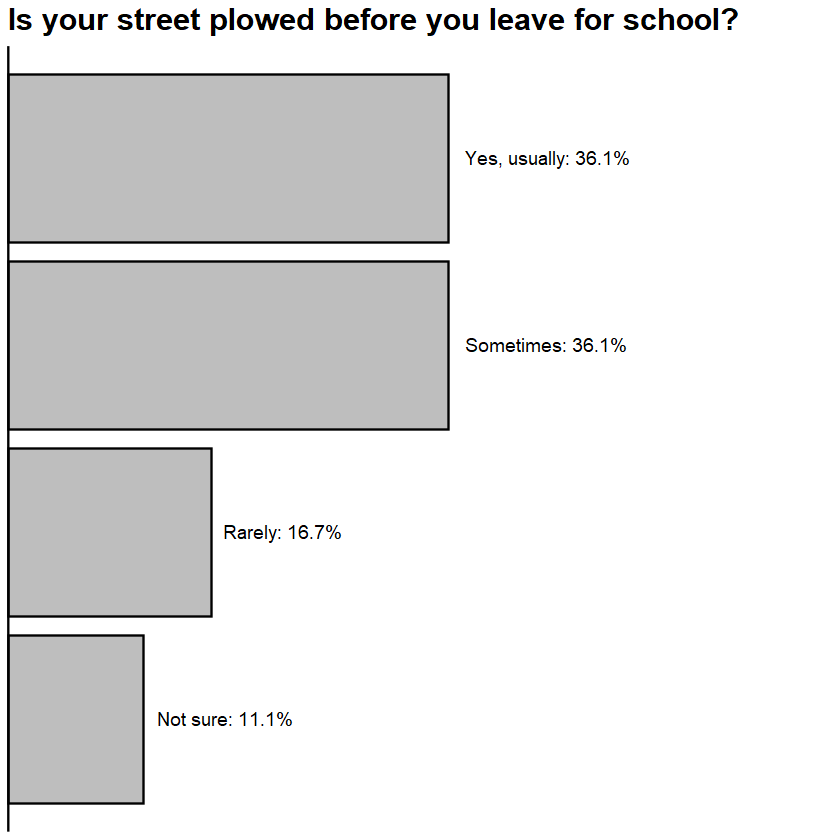

In [36]:
plot_responses_plowing <- 
plot_bar_graph(
  data = response_street_plowed_status_on_snowy_days_count,
  num_var = "percent",
  category_var = "response_street_plowed_status_on_snowy_days",
  fill_color = color_fill,
  plot_title = "Is your street plowed before you leave for school?",
  title_size = font_size_title,
  bar_label_size = font_size_bar,
  right_padding = padding
)

print(plot_responses_plowing)
plot_responses_plowing %>% ggsave(filename=file.path(plot_dir,plot_responses_plowing_filename), width = plot_width, height = plot_height, units = "in")

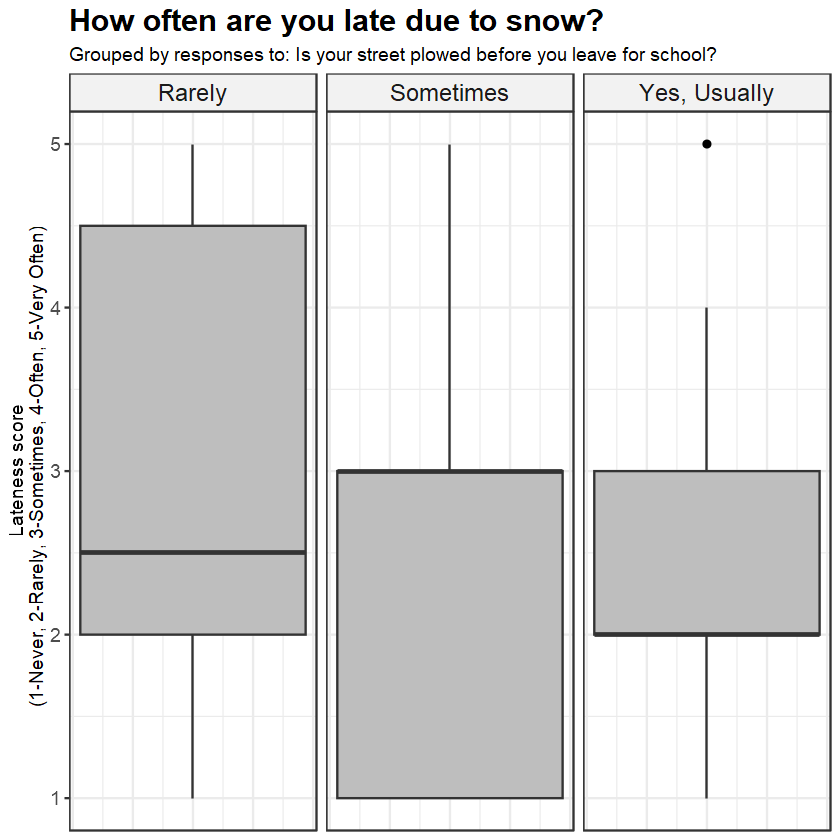

In [38]:
plot_responses_plowing_lateness <- 
plot_boxplots(
  data = response_street_plowed_status_on_snowy_days_combined,
  y_var = "lateness_score",
  facet_var = "scenario",
  fill_color = color_fill,
  plot_title = "How often are you late due to snow?",
  y_label = "Lateness score\n (1-Never, 2-Rarely, 3-Sometimes, 4-Often, 5-Very Often)",
  title_size = font_size_title,
  facet_text_size = font_size_facet,
  y_title_size = font_size_y_title,
  y_text_size = font_size_y_axis,
  plot_subtitle = "Grouped by responses to: Is your street plowed before you leave for school?"
)

print(plot_responses_plowing_lateness)
plot_responses_plowing_lateness %>% ggsave(filename=file.path(plot_dir,plot_responses_plowing_lateness_filename), width = plot_width, height = plot_height, units = "in")

Warning message:
"Removed 2 rows containing non-finite outside the scale range (`stat_boxplot()`)."


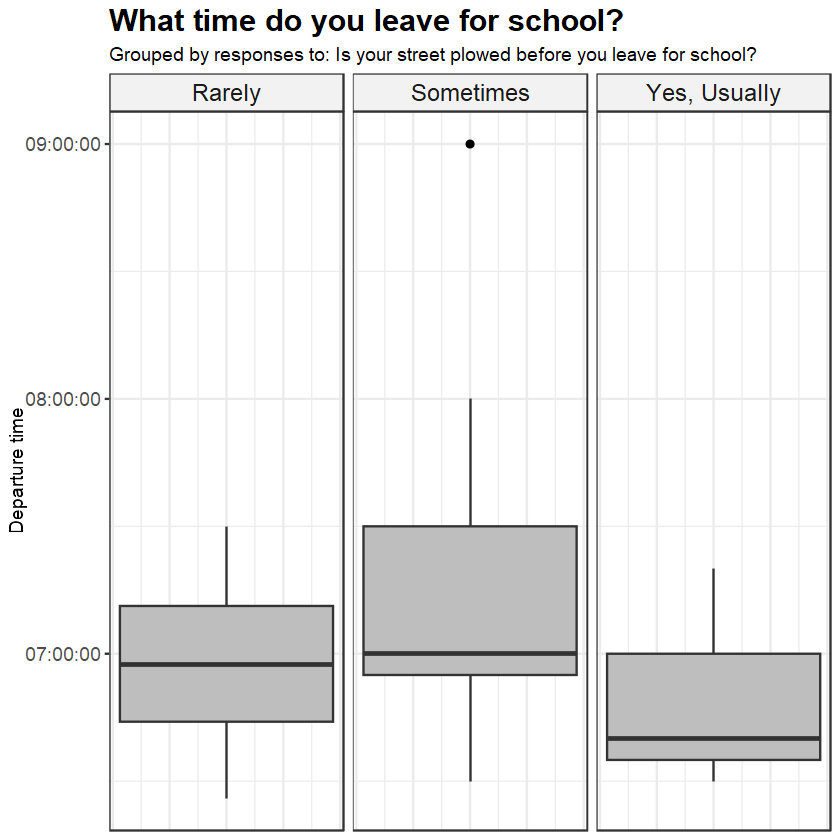

In [42]:
plot_responses_plowing_departure <- 
plot_boxplots(
  data = response_street_plowed_status_on_snowy_days_combined,
  y_var = "response_usual_departure_time_from_home",
  facet_var = "scenario",
  fill_color = color_fill,
  plot_title = "What time do you leave for school?",
  y_label = "Departure time",
  title_size = font_size_title,
  facet_text_size = font_size_facet,
  y_title_size = font_size_y_title,
  y_text_size = font_size_y_axis,
  plot_subtitle = "Grouped by responses to: Is your street plowed before you leave for school?"
)

print(plot_responses_plowing_departure)
plot_responses_plowing_lateness %>% ggsave(filename=file.path(plot_dir,plot_responses_plowing_departure_filename), width = plot_width, height = plot_height, units = "in")

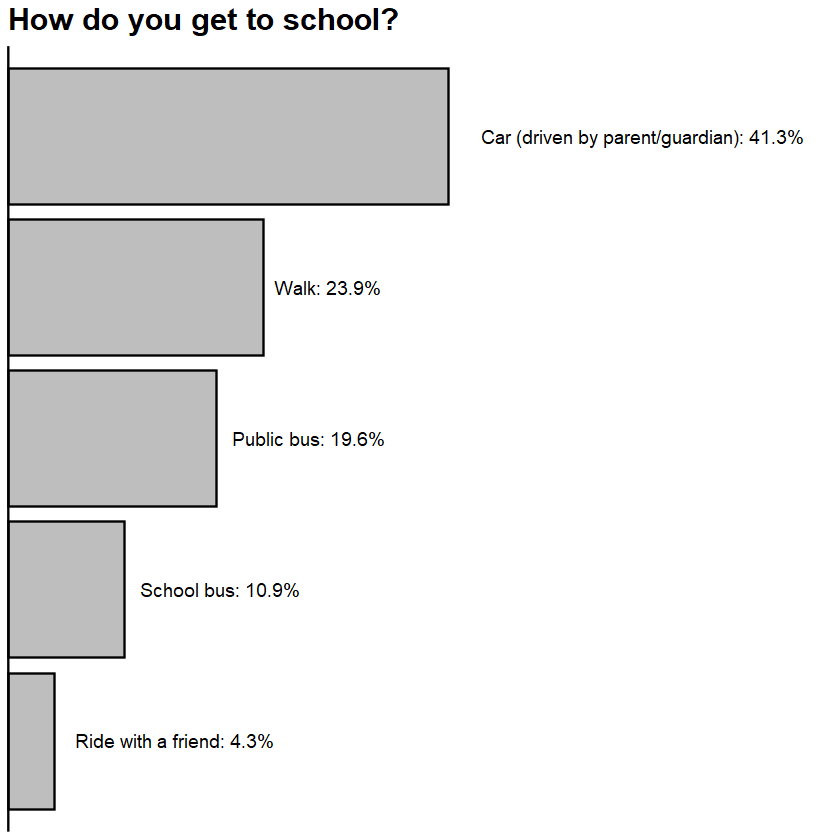

In [46]:
plot_responses_transportation <- 
plot_bar_graph(
  data = response_usual_transportation_mode_to_school_count,
  num_var = "percent",
  category_var = "response_usual_transportation_mode_to_school",
  fill_color = color_fill,
  plot_title = "How do you get to school?",
  title_size = font_size_title,
  bar_label_size = font_size_bar,
  right_padding = padding
)

print(plot_responses_transportation)
plot_responses_plowing %>% ggsave(filename=file.path(plot_dir,plot_responses_transportation_filename), width = plot_width, height = plot_height, units = "in")